In [2]:
import torch

In [3]:
%cd ..

/home/robertflynn/Mimas/exp/exp4/acp21rjf/synthetic-asr-context/exp


In [5]:
!pwd

/home/robertflynn/Mimas/exp/exp4/acp21rjf/synthetic-asr-context/exp


In [6]:
!ls results_history/

GS_history_0.txt      LS_history_0.txt	    ted_history_0.txt
GS_history_1.txt      LS_history_1.txt	    ted_history_1.txt
GS_history_2.txt      LS_history_2.txt	    ted_history_2.txt
GS_history_3.txt      LS_history_3.txt	    ted_history_3.txt
GS_history_4.txt      LS_history_4.txt	    ted_history_4.txt
GS_history_5.txt      LS_history_5.txt	    ted_history_5.txt
GS_history_rsp_1.txt  LS_history_rsp_1.txt  ted_history_rsp_1.txt
GS_history_rsp_2.txt  LS_history_rsp_2.txt  ted_history_rsp_2.txt
GS_history_rsp_3.txt  LS_history_rsp_3.txt  ted_history_rsp_3.txt
GS_history_rsp_4.txt  LS_history_rsp_4.txt  ted_history_rsp_4.txt
GS_history_rsp_5.txt  LS_history_rsp_5.txt  ted_history_rsp_5.txt


In [21]:
def get_wer_from_path(path):
    print(torch.load(path)['wer']*100)

def get_wer_from_txt_file(path):
    with open(path, 'r') as f:
        fi = f.read().splitlines()
    last_line = fi[-1].strip()
    assert last_line.startswith("Total WER:")
    wer = float(last_line.split()[-1].strip('%'))
    return wer

def get_wer_per_history(preamble, min=0, max=5):
    wer_hist_dict = {}
    for i in range(min, max):
        path = f"{preamble}_{i}.txt"
        wer = get_wer_from_txt_file(path)
        wer_hist_dict[i] = wer
    return wer_hist_dict

In [29]:
GS_trunc

{1: 18.8164, 2: 17.9996, 3: 17.6225, 4: 17.3787, 0: 16.7558}

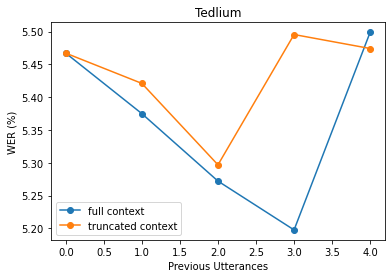

In [38]:
import matplotlib.pyplot as plt
GS_full = get_wer_per_history("./results_history/ted_history")
GS_trunc = get_wer_per_history("./results_history/ted_history_rsp", min=1)
GS_trunc[0] = GS_full[0]  # Add back in the 0 history point for truncated context

plt.plot(sorted(list(GS_full.keys())), [GS_full[k] for k in sorted(GS_full.keys())], label='full context', marker='o')
plt.plot(sorted(list(GS_trunc.keys())), [GS_trunc[k] for k in sorted(GS_trunc.keys())], label='truncated context', marker='o')
plt.xlabel('Previous Utterances')
plt.ylabel('WER (%)')
plt.title('Tedlium')
plt.legend()

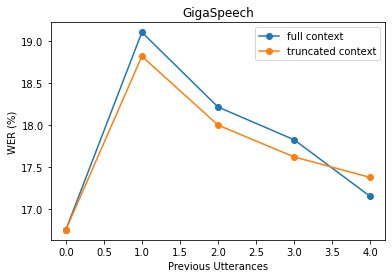

In [39]:
import matplotlib.pyplot as plt
GS_full = get_wer_per_history("./results_history/GS_history")
GS_trunc = get_wer_per_history("./results_history/GS_history_rsp", min=1)
GS_trunc[0] = GS_full[0]  # Add back in the 0 history point for truncated context

plt.plot(sorted(list(GS_full.keys())), [GS_full[k] for k in sorted(GS_full.keys())], label='full context', marker='o')
plt.plot(sorted(list(GS_trunc.keys())), [GS_trunc[k] for k in sorted(GS_trunc.keys())], label='truncated context', marker='o')
plt.xlabel('Previous Utterances')
plt.ylabel('WER (%)')
plt.title('GigaSpeech')
plt.legend()

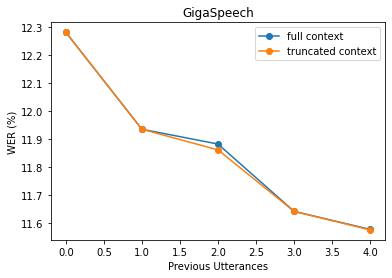

In [ ]:
import matplotlib.pyplot as plt
GS_full = get_wer_per_history("./results_history/LS_history")
GS_trunc = get_wer_per_history("./results_history/LS_history_rsp", min=1)
GS_trunc[0] = GS_full[0]  # Add back in the 0 history point for truncated context

plt.plot(sorted(list(GS_full.keys())), [GS_full[k] for k in sorted(GS_full.keys())], label='full context', marker='o')
plt.plot(sorted(list(GS_trunc.keys())), [GS_trunc[k] for k in sorted(GS_trunc.keys())], label='truncated context', marker='o')
plt.xlabel('Previous Utterances')
plt.ylabel('WER (%)')
plt.title('LibriSpeech')
plt.legend()

In [68]:
get_wer_from_path('./results/results_cross_utt/whisper_turbo_GS_TS_b5.pt')

FileNotFoundError: [Errno 2] No such file or directory: './results/results_cross_utt/whisper_turbo_GS_TS_b5.pt'

In [42]:
a = torch.load("result_longform/whisper_turbo_tedllium_b5_H_ts.pt")

In [39]:
a['hyps'][3]

"I'm Jane McGonigal. I'm a game designer. I've been making games online now for 10 years, and my goal for the next decade is to try to make it as easy to save the world in real life as it is to save the world in online games. Now, I have a plan for this, and it entails convincing more people, including all of you, to spend more time playing bigger and better games. Right now, we spend 3 billion hours a week playing online games. Some of you might be thinking, that's a lot of time to spend playing games, maybe too much time, considering how many urgent problems we have to solve in the real world. But actually, according to my research at the Institute for the Future, it's actually the opposite is true. 3 billion hours a week is not nearly enough gameplay to solve the world's most urgent problems. In fact, I believe that if we want to survive the next century on this planet, we need to increase that total dramatically. I've calculated the total we need at 21 billion hours of gameplay eve